# Comapre Storm Density - Onshore v Calm

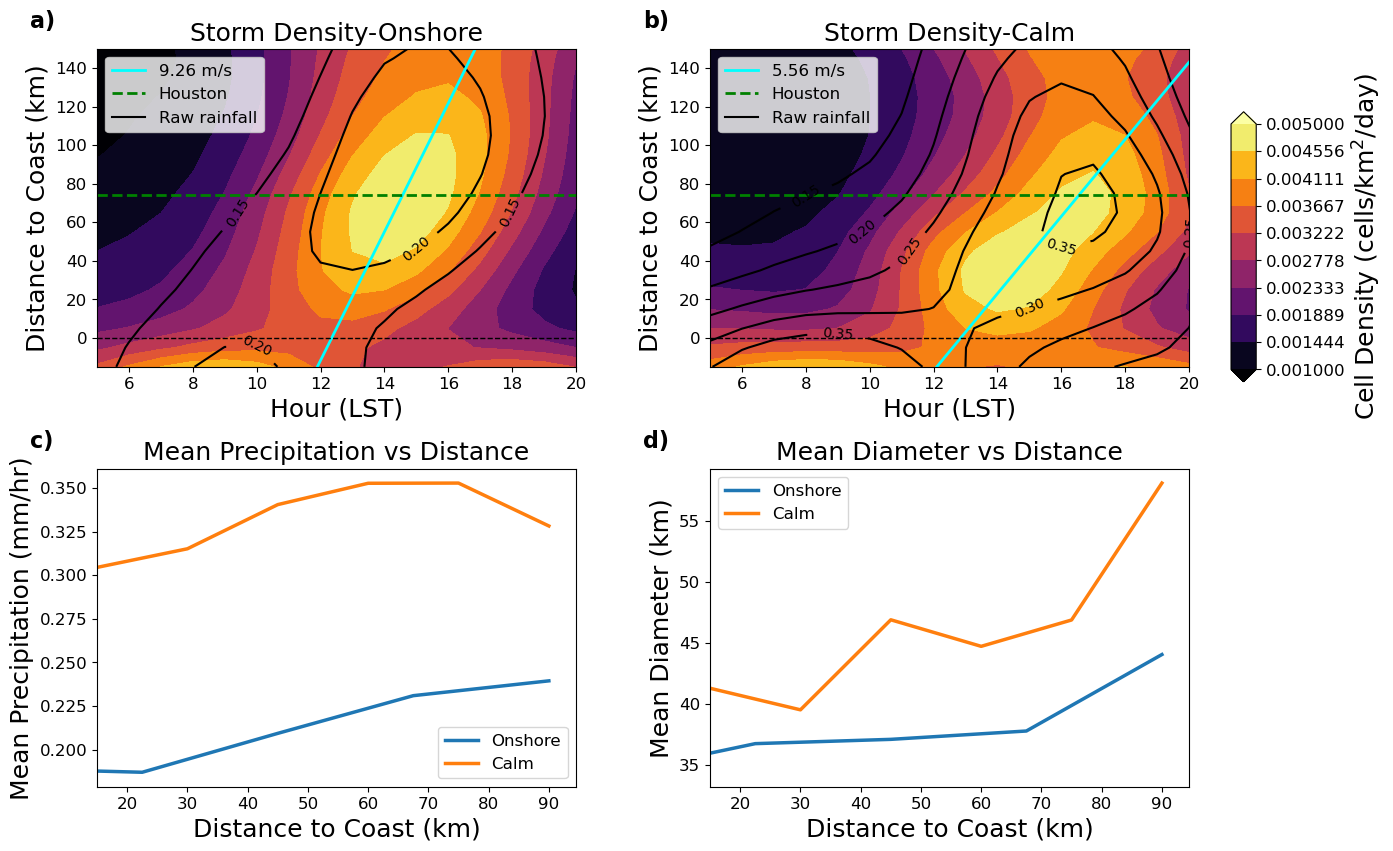

Saved: Plot_Directory\Combined_2x2_Density_Precip_Diameter.png


In [4]:
# -*- coding: utf-8 -*-
# Combined 2x2 figure:
# Top row   -> storm density hovmöllers with rainfall contours
# Bottom row-> mean precipitation vs distance, mean diameter vs distance

import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------
# Plot style
# --------------------
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 16,
    'figure.titlesize': 16
})

# --------------------
# INPUT FILES
# --------------------
# Top row: Hovmöller density panels
f_cl01 = 'Counts_and_ArealDensities_BLACK_CLUST01_Smoothed_rawrf.nc'
f_cl23 = 'Counts_and_ArealDensities_BLACK_CLUST23_Smoothed_rawrf.nc'

# Bottom row: line plots
f_diam_1   = "line_avg_precip_diameter_cl0_1.csv"
f_diam_2   = "line_avg_precip_diameter_cl2_3.csv"
f_precip_1 = "line_avg_composite_rainfall_cl0_1.csv"
f_precip_2 = "line_avg_composite_rainfall_cl2_3.csv"

label1 = "Onshore"
label2 = "Calm"

# Output
outdir = "Plot_Directory"
os.makedirs(outdir, exist_ok=True)
out_png = os.path.join(outdir, "Combined_2x2_Density_Precip_Diameter.png")

# --------------------
# HELPERS
# --------------------
def fit_line_from_fd(fd, hours, dist_km, window_km=20):
    peak_idx_flat = np.nanargmax(fd)
    peak_dist_idx, _ = np.unravel_index(peak_idx_flat, fd.shape)
    peak_dist_km = dist_km[peak_dist_idx]

    fit_mask = (dist_km >= peak_dist_km - window_km) & (dist_km <= peak_dist_km + window_km)
    distances_fit = dist_km[fit_mask]

    peak_hours = []
    for di in np.where(fit_mask)[0]:
        time_profile = fd[di, :]
        h_idx = np.nanargmax(time_profile)
        peak_hours.append(hours[h_idx])
    peak_hours = np.array(peak_hours)

    theta, intercept_time = np.polyfit(distances_fit, peak_hours, 1)
    slope_dist_per_hr = 1 / theta
    intercept_dist = -intercept_time / theta
    effective_speed = slope_dist_per_hr * 1000 / 3600

    return slope_dist_per_hr, intercept_dist, effective_speed

def load_case(f):
    ds = xr.open_dataset(f).sel(distance_km=slice(155, -15))

    fd = ds['areal_density_per_100km2_day_smoothed'].values
    hours = ds['hour'].values
    dist_km = ds['distance_km'].values

    if 'raw_rainfall_binned_smoothed' in ds.variables:
        rr = ds['raw_rainfall_binned_smoothed'].values
        rr_label = "Raw rainfall"
    elif 'raw_rainfall_binned' in ds.variables:
        rr = ds['raw_rainfall_binned'].values
        rr_label = "Raw rainfall"
    else:
        raise KeyError(
            f"No rainfall variable found in {f}. "
            "Expected 'raw_rainfall_binned_smoothed' or 'raw_rainfall_binned'."
        )

    slope_dist_per_hr, intercept_dist, effective_speed = fit_line_from_fd(fd, hours, dist_km)

    return {
        "fd": fd,
        "rr": rr,
        "rr_label": rr_label,
        "hours": hours,
        "dist_km": dist_km,
        "slope": slope_dist_per_hr,
        "intercept": intercept_dist,
        "speed": effective_speed
    }

def read_table(path: str, required_cols) -> pd.DataFrame:
    ext = os.path.splitext(path)[1].lower()

    if ext in [".xlsx", ".xls"]:
        df = pd.read_excel(path)
    elif ext == ".csv":
        df = pd.read_csv(path)
    elif ext in [".txt", ".tsv"]:
        df = pd.read_csv(path, sep="\t")
    else:
        raise ValueError(f"Unsupported file type: {ext} (use .csv, .tsv/.txt, .xlsx)")

    df.columns = [c.strip() for c in df.columns]

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}\nFound: {list(df.columns)}")

    return df.sort_values("distance_km").reset_index(drop=True)

# --------------------
# LOAD DATA
# --------------------
cl01 = load_case(f_cl01)
cl23 = load_case(f_cl23)

df_d1 = read_table(f_diam_1, ["distance_km", "mean_diameter_km"])
df_d2 = read_table(f_diam_2, ["distance_km", "mean_diameter_km"])

df_p1 = read_table(f_precip_1, ["distance_km", "mean_precip_mmhr"])
df_p2 = read_table(f_precip_2, ["distance_km", "mean_precip_mmhr"])

# --------------------
# LEVELS
# --------------------
dlevels = np.linspace(0.001, 0.005, 10)
rlevels = [0.15, 0.20, 0.25, 0.30, 0.35]

# --------------------
# FIGURE
# --------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ax00, ax01 = axes[0, 0], axes[0, 1]
ax10, ax11 = axes[1, 0], axes[1, 1]

# --------------------
# TOP ROW: DENSITY PANELS
# --------------------
cases = [
    (ax00, cl01, "Storm Density-Onshore"),
    (ax01, cl23, "Storm Density-Calm")
]

cf = None

for ax, case, title in cases:
    fd = case["fd"]
    rr = case["rr"]
    rr_label = case["rr_label"]
    hours = case["hours"]
    dist_km = case["dist_km"]
    slope = case["slope"]
    intercept = case["intercept"]
    speed = case["speed"]

    cf = ax.contourf(hours, dist_km, fd, levels=dlevels, cmap='inferno', extend='both')

    cs = ax.contour(hours, dist_km, rr, levels=rlevels, colors='black', linewidths=1.5)
    ax.clabel(cs, fmt="%.2f", fontsize=10)

    line_times = np.array([10, 20])
    line_distances = slope * line_times + intercept
    ax.plot(line_times, line_distances, color='cyan', linewidth=2,
            label=f'{speed:.2f} m/s')

    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.axhline(74.3, color='g', linestyle='--', linewidth=2, label='Houston')
    ax.plot([], [], color='black', linewidth=1.5, label=rr_label)

    ax.set_xlim(5, 20)
    ax.set_ylim(-15, 150)
    ax.set_xlabel('Hour (LST)')
    ax.set_title(title)
    ax.legend(loc='upper left', frameon=True, fontsize=12)

ax00.set_ylabel('Distance to Coast (km)')
ax01.set_ylabel('Distance to Coast (km)')

# --------------------
# BOTTOM LEFT: MEAN PRECIP
# --------------------
ax10.plot(df_p1["distance_km"], df_p1["mean_precip_mmhr"], linewidth=2.5, label=label1)
ax10.plot(df_p2["distance_km"], df_p2["mean_precip_mmhr"], linewidth=2.5, label=label2)
ax10.axvline(0, color='k', linestyle='--', linewidth=1)
ax10.set_xlabel("Distance to Coast (km)")
ax10.set_ylabel("Mean Precipitation (mm/hr)")
ax10.set_title("Mean Precipitation vs Distance")
ax10.set_xlim(left=15)
ax10.legend(loc="best", frameon=True, fontsize=12)

# --------------------
# BOTTOM RIGHT: MEAN DIAMETER
# --------------------
ax11.plot(df_d1["distance_km"], df_d1["mean_diameter_km"], linewidth=2.5, label=label1)
ax11.plot(df_d2["distance_km"], df_d2["mean_diameter_km"], linewidth=2.5, label=label2)
ax11.axvline(0, color='k', linestyle='--', linewidth=1)
ax11.set_xlabel("Distance to Coast (km)")
ax11.set_ylabel("Mean Diameter (km)")
ax11.set_title("Mean Diameter vs Distance")
ax11.set_xlim(left=15)
ax11.legend(loc="best", frameon=True, fontsize=12)

# --------------------
# PANEL LABELS OUTSIDE AXES
# --------------------
panel_labels = {
    ax00: "a)",
    ax01: "b)",
    ax10: "c)",
    ax11: "d)"
}

for ax, lab in panel_labels.items():
    ax.text(
        -0.14, 1.05, lab,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='bottom',
        ha='left',
        clip_on=False
    )

# --------------------
# LAYOUT + COLORBAR
# --------------------
fig.subplots_adjust(left=0.10, right=0.88, top=0.93, wspace=0.28, hspace=0.32)

cax = fig.add_axes([0.91, 0.56, 0.018, 0.30])
cbar = fig.colorbar(cf, cax=cax)
cbar.set_label('Cell Density (cells/km$^2$/day)')

# --------------------
# SAVE
# --------------------
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")